# Pertemuan 6 — Praktikum 2: Hyperparameter dan Evaluasi HDBSCAN

Praktikum ini memusatkan pembahasan pada HDBSCAN saja. Tujuannya adalah melihat pengaruh hyperparameter `min_cluster_size`, `min_samples`, dan `cut_distance` terhadap jumlah klaster serta banyaknya noise, kemudian menilai kualitas hasil klasterisasi dengan Silhouette Score dan Davies-Bouldin Index.

Data yang dipakai adalah dataset sintetis dengan empat kelompok berkepadatan berbeda, sama seperti pada Praktikum 1.

Sumber: [Praktikum 2](https://polinema.gitbook.io/jti-modul-praktikum-pembelajaran-mesin-2025-2026/js05-klasterisasi-hierarki/praktikum-2).


## 1. Menyiapkan data dan fungsi visualisasi

Sel berikut memuat pustaka, membuat kembali dataset empat kelompok berkepadatan berbeda, dan mendefinisikan fungsi `plot` yang sama dengan Praktikum 1. Dataset dibentuk ulang agar notebook ini dapat dijalankan sendiri tanpa bergantung pada notebook sebelumnya.


In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, davies_bouldin_score
import hdbscan

def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    labels = labels if labels is not None else np.ones(X.shape[0])
    probabilities = probabilities if probabilities is not None else np.ones(X.shape[0])
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    proba_map = {idx: probabilities[idx] for idx in range(len(labels))}

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]  # warna hitam untuk noise
        class_index = (labels == k).nonzero()[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "x" if k == -1 else "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=4 if k == -1 else 1 + 5 * proba_map[ci],
            )
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else "Estimated"
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" | {parameters_str}"
    ax.set_title(title)
    plt.tight_layout()

centers = [[-0.85, -0.85], [-0.85, 0.85], [3, 3], [3, -3]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=[0.2, 0.35, 1.35, 1.35], random_state=0
)


## 2. Eksperimen hyperparameter `min_cluster_size`

`min_cluster_size` menentukan jumlah minimum titik agar sebuah kelompok dianggap sebagai klaster. Nilai yang kecil memungkinkan terbentuknya banyak klaster kecil, sedangkan nilai yang besar menggabungkan atau menghapus klaster kecil. Percobaan memakai nilai `5`, `3`, dan `25`.


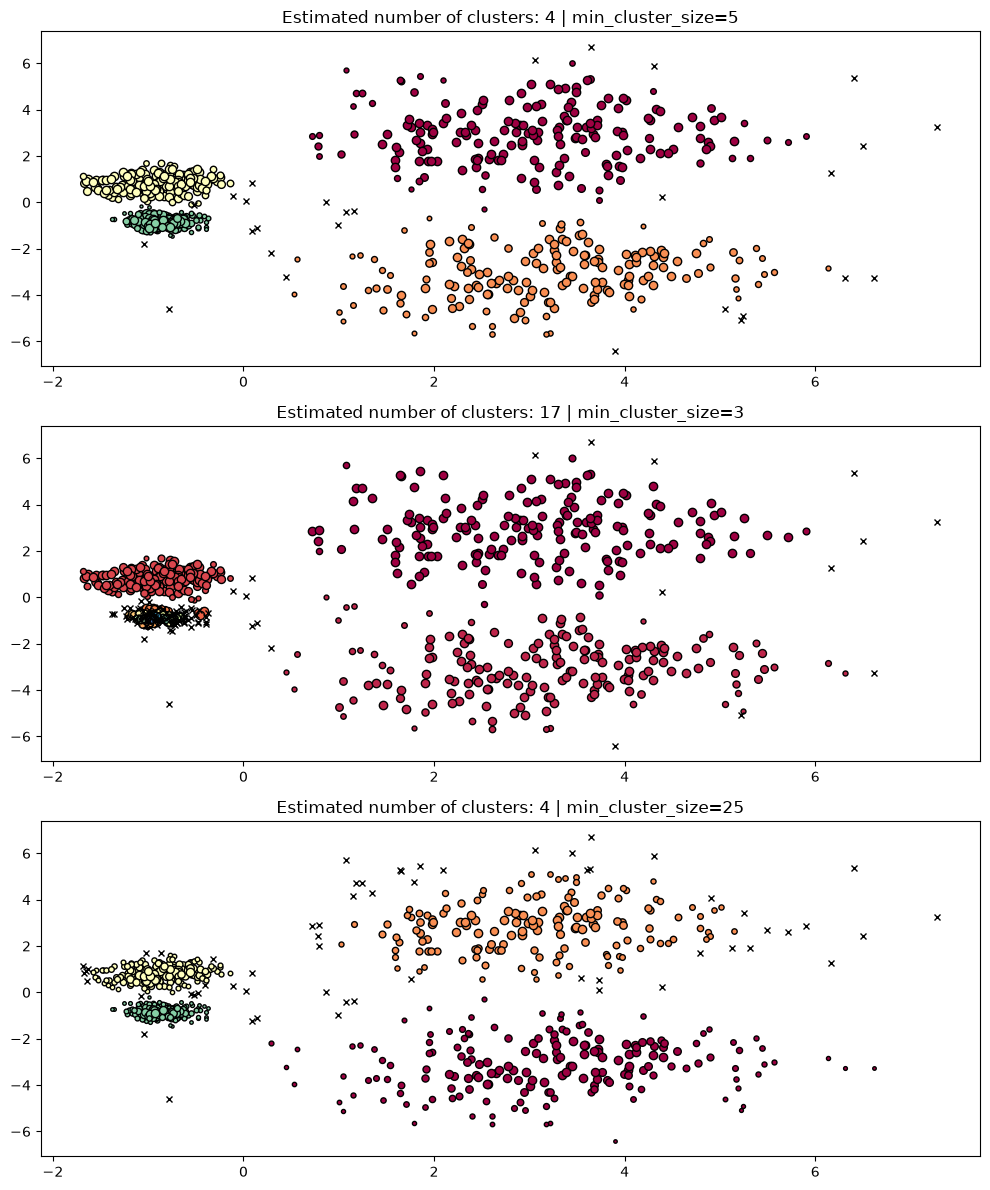

In [2]:
PARAM = ({"min_cluster_size": 5}, {"min_cluster_size": 3}, {"min_cluster_size": 25})
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    hdb = hdbscan.HDBSCAN(**param).fit(X)
    plot(X, hdb.labels_, hdb.probabilities_, param, ax=axes[i])
plt.show()


## 3. Eksperimen hyperparameter `min_samples`

`min_samples` mengatur seberapa konservatif sebuah titik dianggap padat. Nilai kecil membuat algoritma lebih mudah memasukkan titik ke klaster, sedangkan nilai besar menambah jumlah titik yang ditandai sebagai noise. Percobaan memakai `min_cluster_size = 20` dengan `min_samples` `5`, `3`, dan `25`.


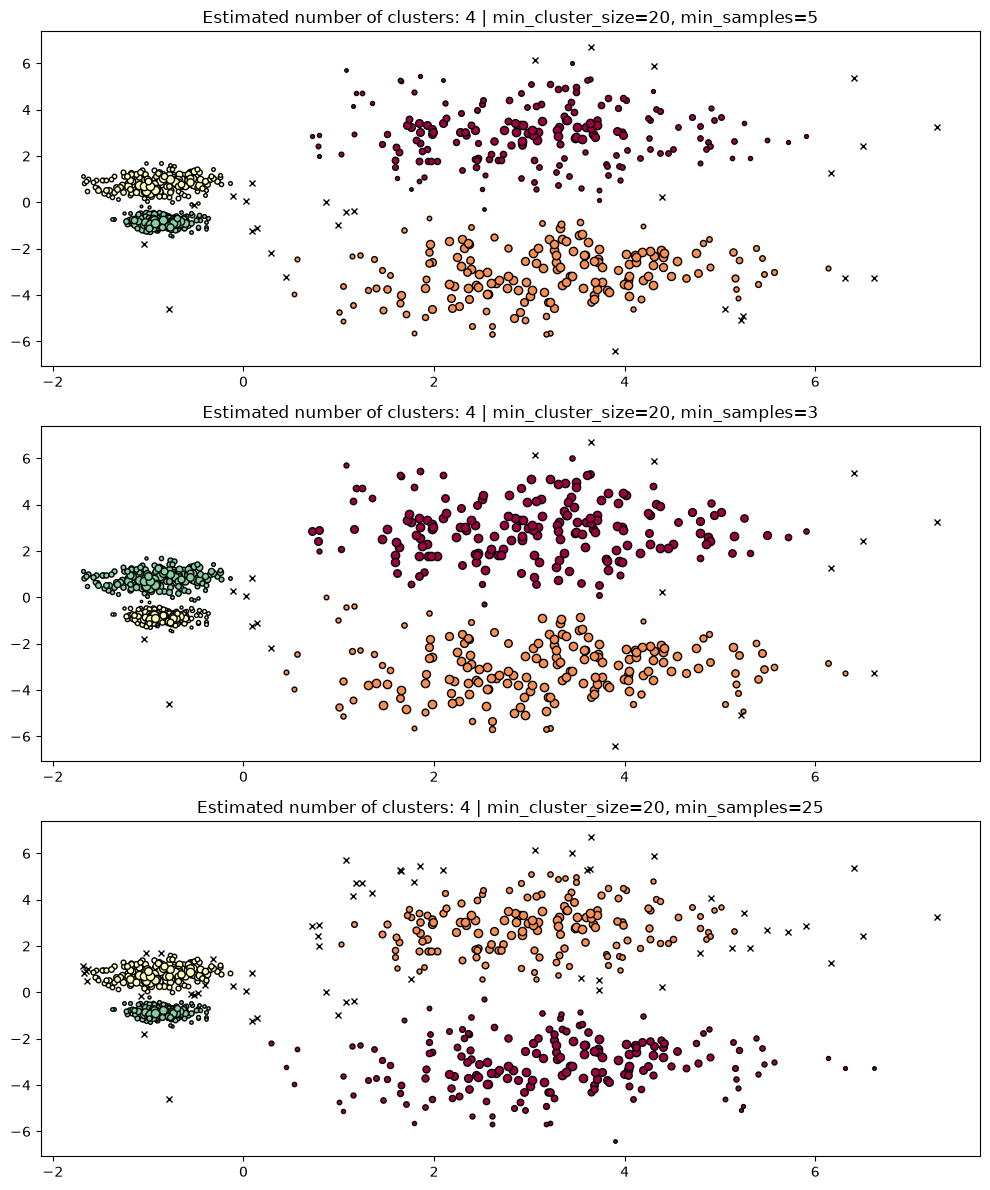

In [3]:
PARAM = (
    {"min_cluster_size": 20, "min_samples": 5},
    {"min_cluster_size": 20, "min_samples": 3},
    {"min_cluster_size": 20, "min_samples": 25},
)
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    hdb = hdbscan.HDBSCAN(**param).fit(X)
    plot(X, hdb.labels_, hdb.probabilities_, param, ax=axes[i])
plt.show()


## 4. Klasterisasi DBSCAN dari pohon HDBSCAN

HDBSCAN menyimpan struktur hierarki berupa pohon klaster. Metode `dbscan_clustering` memotong pohon tersebut pada jarak tertentu (`cut_distance`). Nilai `cut_distance` yang kecil menghasilkan banyak klaster kecil, sedangkan nilai yang besar menggabungkan klaster menjadi lebih sedikit.


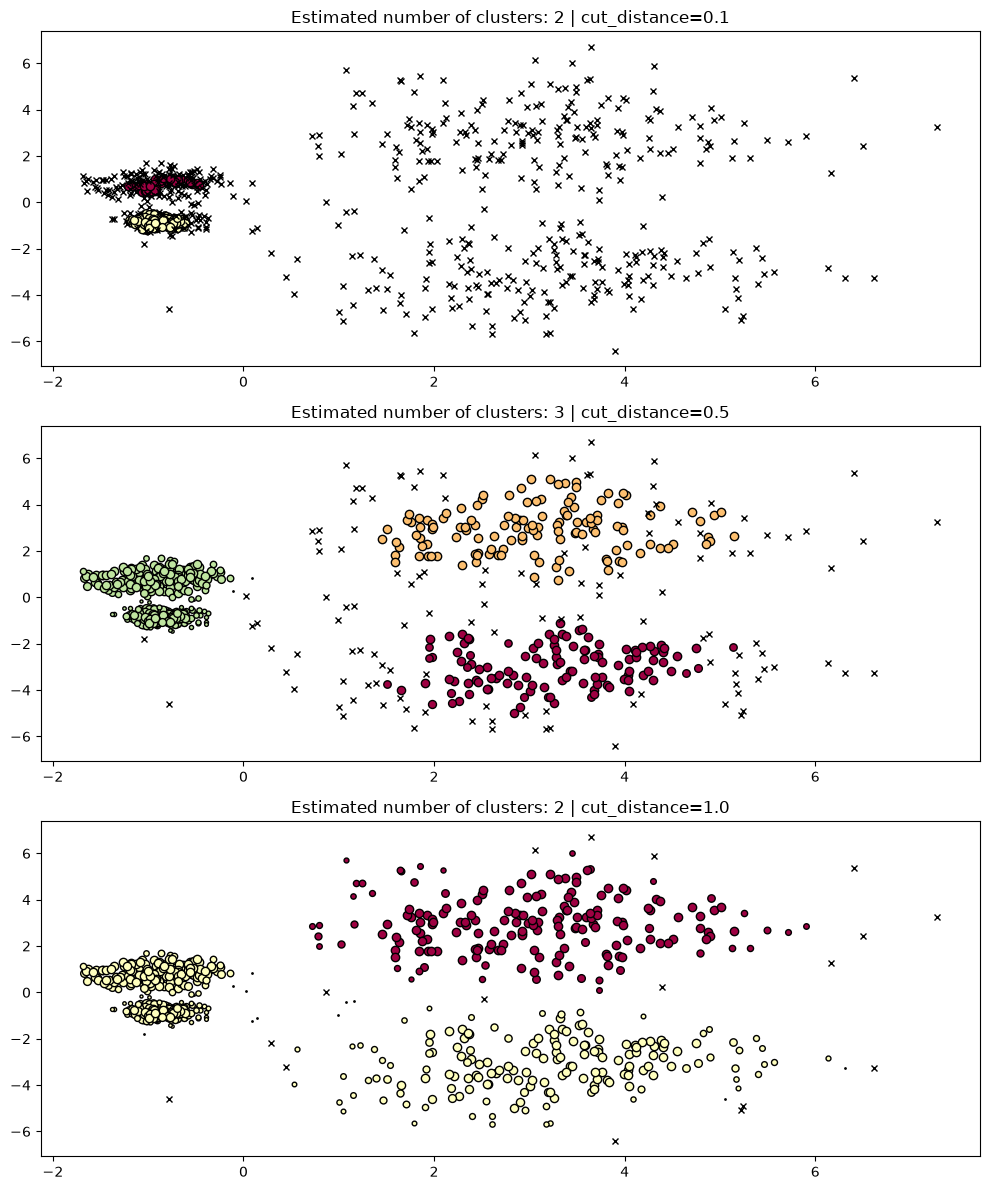

In [4]:
PARAM = (
    {"cut_distance": 0.1},
    {"cut_distance": 0.5},
    {"cut_distance": 1.0},
)
hdb = hdbscan.HDBSCAN().fit(X)
fig, axes = plt.subplots(len(PARAM), 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    labels = hdb.dbscan_clustering(**param)
    plot(X, labels, hdb.probabilities_, param, ax=axes[i])
plt.show()


## 5. Evaluasi dengan Silhouette Score

Silhouette Score mengukur seberapa cocok sebuah titik dengan klasternya dibandingkan klaster terdekat lain. Nilainya berkisar dari `-1` sampai `1`; nilai yang mendekati `1` menandakan klaster yang padat dan terpisah dengan baik, nilai di sekitar `0` berarti titik berada di perbatasan klaster, dan nilai negatif menandakan kemungkinan salah klaster. Perhitungan dilakukan tanpa titik noise karena noise bukan klaster biasa.


In [5]:
hdb = hdbscan.HDBSCAN().fit(X)
labels = hdb.labels_
mask = labels != -1

sil_score = silhouette_score(X[mask], labels[mask])
print(f"Jumlah klaster: {len(set(labels[mask]))}")
print(f"Jumlah noise  : {int((labels == -1).sum())}")
print(f"Silhouette Score: {sil_score:.4f}")


Jumlah klaster: 4
Jumlah noise  : 28
Silhouette Score: 0.6224


## 6. Evaluasi dengan Davies-Bouldin Index

Davies-Bouldin Index mengukur kualitas klasterisasi dari jarak antar klaster dan sebaran di dalam klaster. Semakin kecil nilainya, semakin baik pemisahan antar klaster. Nilai yang besar menandakan klaster saling tumpang tindih. Seperti pada Silhouette Score, perhitungan memakai data tanpa noise.


In [6]:
dbi_score = davies_bouldin_score(X[mask], labels[mask])
print(f"Davies-Bouldin Index: {dbi_score:.4f}")


Davies-Bouldin Index: 0.4536


## 7. Visualisasi hasil evaluasi

Kedua nilai evaluasi ditampilkan dalam satu grafik batang agar mudah dibandingkan. Silhouette Score yang tinggi dan Davies-Bouldin Index yang rendah menunjukkan hasil klasterisasi yang baik.


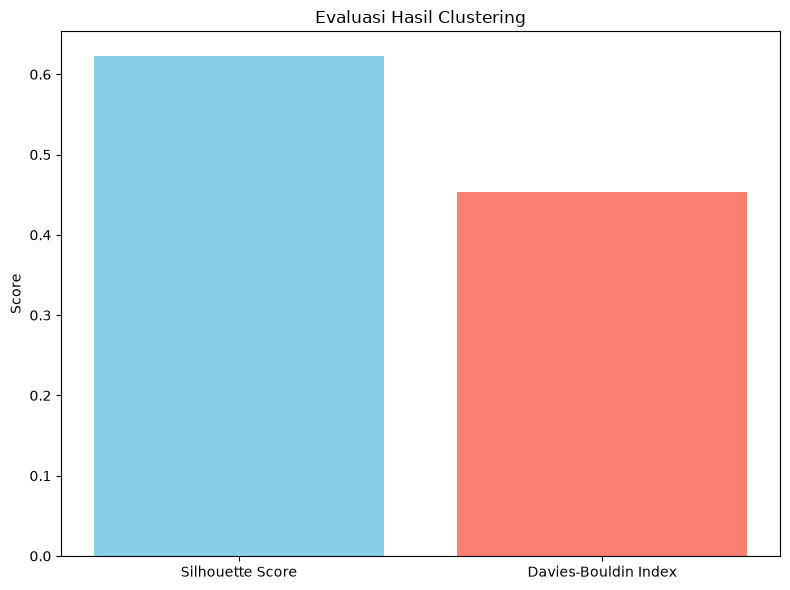

In [ ]:
scores = {
    "Silhouette Score": sil_score,
    "Davies-Bouldin Index": dbi_score,
}

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(scores.keys(), scores.values(), color=['skyblue', 'salmon'])
ax.set_title("Evaluasi Hasil Clustering")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()


## 8. Ringkasan eksperimen

Sel berikut merangkum pengaruh `min_cluster_size` terhadap jumlah klaster, banyaknya noise, dan kedua nilai evaluasi. Tabel ini membantu melihat hubungan antara nilai hyperparameter dan kualitas hasil klasterisasi.


In [8]:
hasil = []
for param in ({"min_cluster_size": 3}, {"min_cluster_size": 5}, {"min_cluster_size": 25}):
    hdb = hdbscan.HDBSCAN(**param).fit(X)
    lab = hdb.labels_
    m = lab != -1
    n_klaster = len(set(lab[m]))
    sil = np.nan
    dbi = np.nan
    if 2 <= n_klaster < int(m.sum()):
        sil = silhouette_score(X[m], lab[m])
        dbi = davies_bouldin_score(X[m], lab[m])
    hasil.append({
        "min_cluster_size": param["min_cluster_size"],
        "Klaster": n_klaster,
        "Noise": int((lab == -1).sum()),
        "Silhouette": round(sil, 4),
        "Davies-Bouldin": round(dbi, 4),
    })

display(pd.DataFrame(hasil))


,min_cluster_size,Klaster,Noise,Silhouette,Davies-Bouldin
0,3,17,104,0.5076,0.5297
1,5,4,28,0.6224,0.4536
2,25,4,61,0.6422,0.4314


## Kesimpulan

Hasil klasterisasi HDBSCAN dipengaruhi oleh `min_cluster_size`, `min_samples`, dan `cut_distance`. Nilai `min_cluster_size` yang kecil menghasilkan banyak klaster kecil, sedangkan nilai besar mengurangi jumlah klaster. Nilai `min_samples` yang besar menambah jumlah noise. Silhouette Score dan Davies-Bouldin Index dipakai bersama karena keduanya menilai kepadatan dan pemisahan klaster dari sudut yang berbeda.
